(100,)


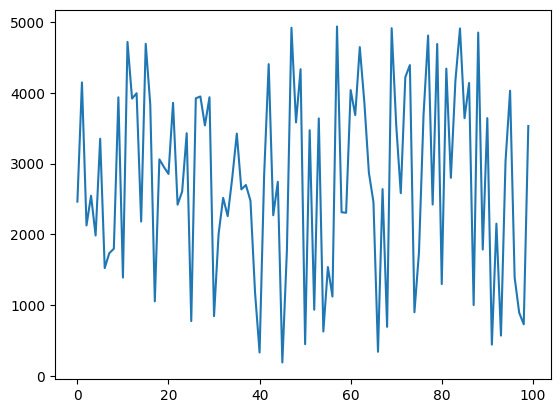

In [16]:
import numpy as np
from matplotlib import pyplot as plt

img_array = np.load('D:/Kaustubh/Transformer_Geometry_Observatory_Part-1/results_tgo_v1/trajectory_indices.npy')
print(img_array.shape)
plt.plot(img_array)
plt.show()

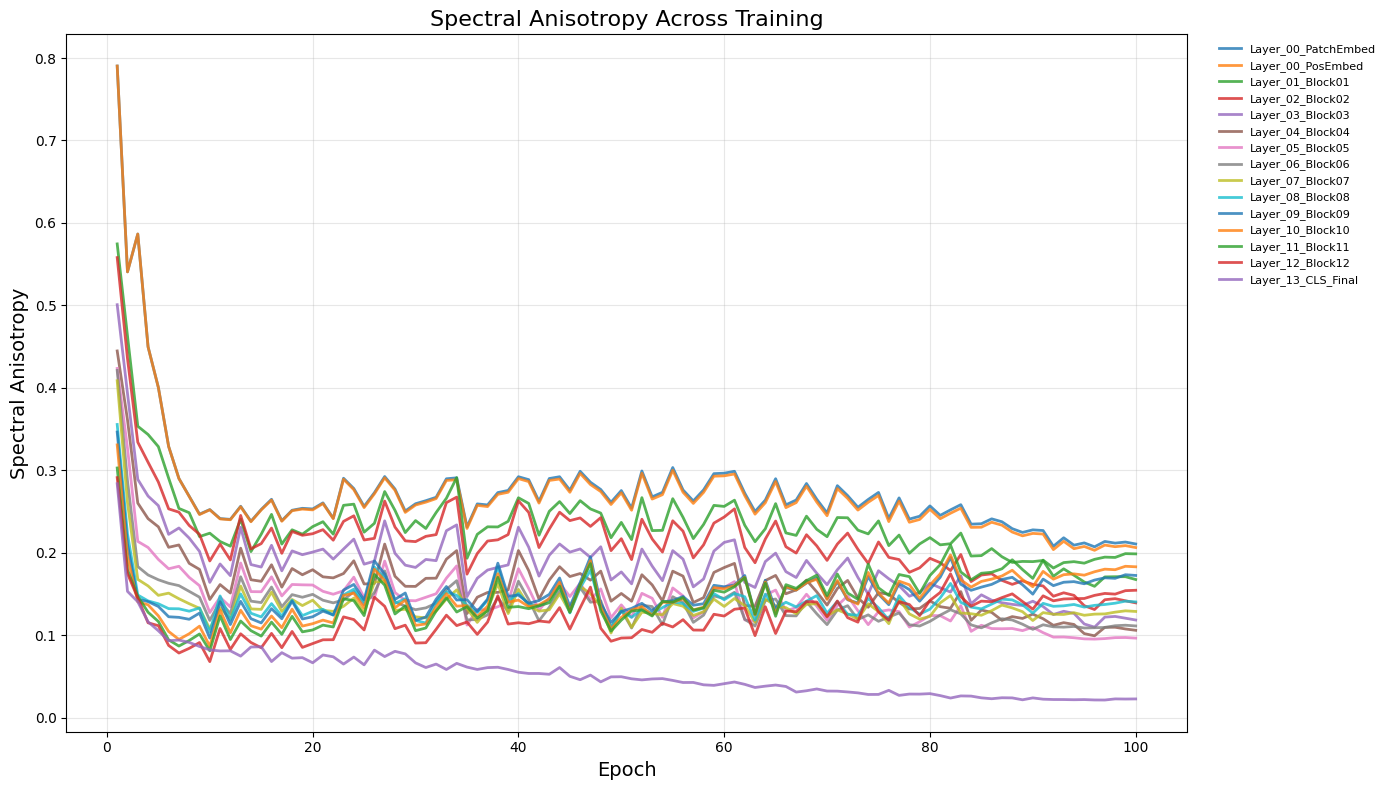

In [4]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

jsonl_path = "D:/Kaustubh/Transformer_Geometry_Observatory_Part-1/results/epoch_summaries.jsonl"

layer_data = defaultdict(list)

with open(jsonl_path, "r") as f:
    for line in f:
        record = json.loads(line)

        epoch = record["epoch"]

        for layer_name, metrics in record["layers"].items():
            layer_data[layer_name].append(
                (epoch, metrics["spectral_anisotropy"])
            )

plt.figure(figsize=(14, 8))

for layer_name, values in layer_data.items():
    values = sorted(values, key=lambda x: x[0])

    epochs = [v[0] for v in values]
    entropies = [v[1] for v in values]

    plt.plot(
        epochs,
        entropies,
        linewidth=2,
        alpha=0.8,
        label=layer_name
    )

plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Spectral Anisotropy", fontsize=14)
plt.title("Spectral Anisotropy Across Training", fontsize=16)

plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    frameon=False,
    ncol=1
)

plt.tight_layout()

plt.savefig(
    "spectral_entropy_all_layers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()